In [1]:
import os
import sys

# Trick to plot with tex
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

sys.path.append(
    "/home/guerrini/sp_validation/cosmo_inference/scripts/"
)

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import chain_postprocessing as cp

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_single_plotter(width_inch=30)

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"
root_external = "/n09data/guerrini/output_chains/ext_data/"
blind = "B"

roots = [
    f"SP_v1.4.6.3_leak_corr_{blind}",
    f"SP_v1.4.6.3_{blind}_fiducial_config",
    "DES_Y3_cell",
    "KiDS-Legacy_cosebis",
    "KiDS-Legacy_bandpowers",
    "HSC_Y3_cell",
]

categories = [
    "harmonic",
    "configuration",
    "external",
    "external",
    "external",
    "external"
]

print(roots)

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/cosmological_constraints_weak_lensing", exist_ok=True)

['SP_v1.4.6.3_leak_corr_B', 'SP_v1.4.6.3_B_fiducial_config', 'DES_Y3_cell', 'KiDS-Legacy_cosebis', 'KiDS-Legacy_bandpowers', 'HSC_Y3_cell']


In [2]:
chains = []
for i, root in enumerate(roots):
    category = categories[i]
    if category != "external":
        if category == 'configuration':
            path_samples = os.path.join(
                root_dir,
                f"{root}/samples_{root}.txt"
            )
            path_getdist = os.path.join(
                root_dir,
                f"{root}/getdist_{root}"
            )
        elif category == 'harmonic':
            path_samples = os.path.join(
                root_dir,
                f"{root}/{root}/samples_{root}_cell.txt"
            )
            path_getdist = os.path.join(
                root_dir,
                f"{root}/{root}/getdist_{root}"
            )
        elif category == "external_compute_sample":
            path_samples = os.path.join(
                root_dir,
                f"ext_data/{root}/samples_{root}.txt"
            )
            path_getdist = os.path.join(
                root_dir,
                f"ext_data/{root}/getdist_{root}"
            )
        else:
            raise ValueError(f"The category, {category}, of {root} is not correct")
        
        if category == "external_compute_sample" and "Legacy" in root:
            chain_type="nautilus"
        else:
            chain_type="polychord"
        cp.load_samples_and_write_paramnames(path_samples, path_getdist+".paramnames", chain_type=chain_type)
        cp.write_samples_getdist_format(path_samples, path_getdist+".txt", chain_type=chain_type)
        chains.append(
            cp.load_chain(path_getdist, smoothing_scale=0.5)
        )
    else:
        path_getdist = os.path.join(
            root_dir,
            f"ext_data/{root}/getdist_{root}"
        )
        chains.append(
            cp.load_chain(path_getdist)
        )

/n09data/guerrini/output_chains/SP_v1.4.6.3_leak_corr_B/SP_v1.4.6.3_leak_corr_B/getdist_SP_v1.4.6.3_leak_corr_B.txt
Removed no burn in
/n09data/guerrini/output_chains/SP_v1.4.6.3_B_fiducial_config/getdist_SP_v1.4.6.3_B_fiducial_config.txt
Removed no burn in


<Figure size 3000x2250 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [3]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8', 'S_8', 's_8_input', 'logt_agn','a','m1','bias_1']
label_list = label_list = [r'\Omega_{\rm m}', r'\omega_{\rm b} h^2', r'h_0', r'n_{\rm s}', r'\sigma_8', r'S_8', r'\log T_{\rm AGN}', r'A_{\rm IA}', r'm_1', r'\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        try:
            param_names.parWithName(name).label = label
        except:
            pass

In [4]:
def adjust_paramname_chain(chain, current_name, target_name, label):
    """
    Adjusts the parameter name and label in a GetDist chain.
    """
    param_names = chain.getParamNames()
    par = param_names.parWithName(current_name)

    par.label = label
    par.name = target_name

    chain.setParamNames(param_names)

def derive_parameter_S8(chain):
    """
    Derives the S_8 parameter from Omega_m and Sigma_8 in a GetDist chain.
    S_8 = Sigma_8 * (Omega_m / 0.3) ** 0.5
    """
    omega_m = chain.getParams().OMEGA_M
    sigma_8 = chain.getParams().SIGMA_8

    s_8 = sigma_8 * (omega_m / 0.3) ** 0.5

    chain.addDerived(s_8, name='S_8', label='S_8')

    return chain
    


In [5]:
if 'KiDS-1000' in roots:
    idx = roots.index('KiDS-1000')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'HSC_Y3' in roots:
    idx = roots.index('HSC_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'DES+KiDS' in roots:
    idx = roots.index('DES+KiDS')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')

if 'DES_Y3' in roots:
    idx = roots.index('DES_Y3')
    adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', '\Omega_m')
    derive_parameter_S8(chains[idx])

if 'KiDS-Legacy_cosebis' in roots:
    idx = roots.index('KiDS-Legacy_cosebis')
    derive_parameter_S8(chains[idx])

if 'KiDS-Legacy_bandpowers' in roots:
    idx = roots.index('KiDS-Legacy_bandpowers')
    derive_parameter_S8(chains[idx])

if 'DES_Y3_cell' in roots:
    idx = roots.index('DES_Y3_cell')
    cp.adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')
    cp.derive_parameter_S8(chains[idx])

if 'HSC_Y3_cell' in roots:
    idx = roots.index('HSC_Y3_cell')
    cp.adjust_paramname_chain(chains[idx], 'omega_m', 'OMEGA_M', r'\Omega_{\rm m}')

/tmp/ipykernel_619187/4778921.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_619187/4778921.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.pdf", bbox_inches='tight')
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


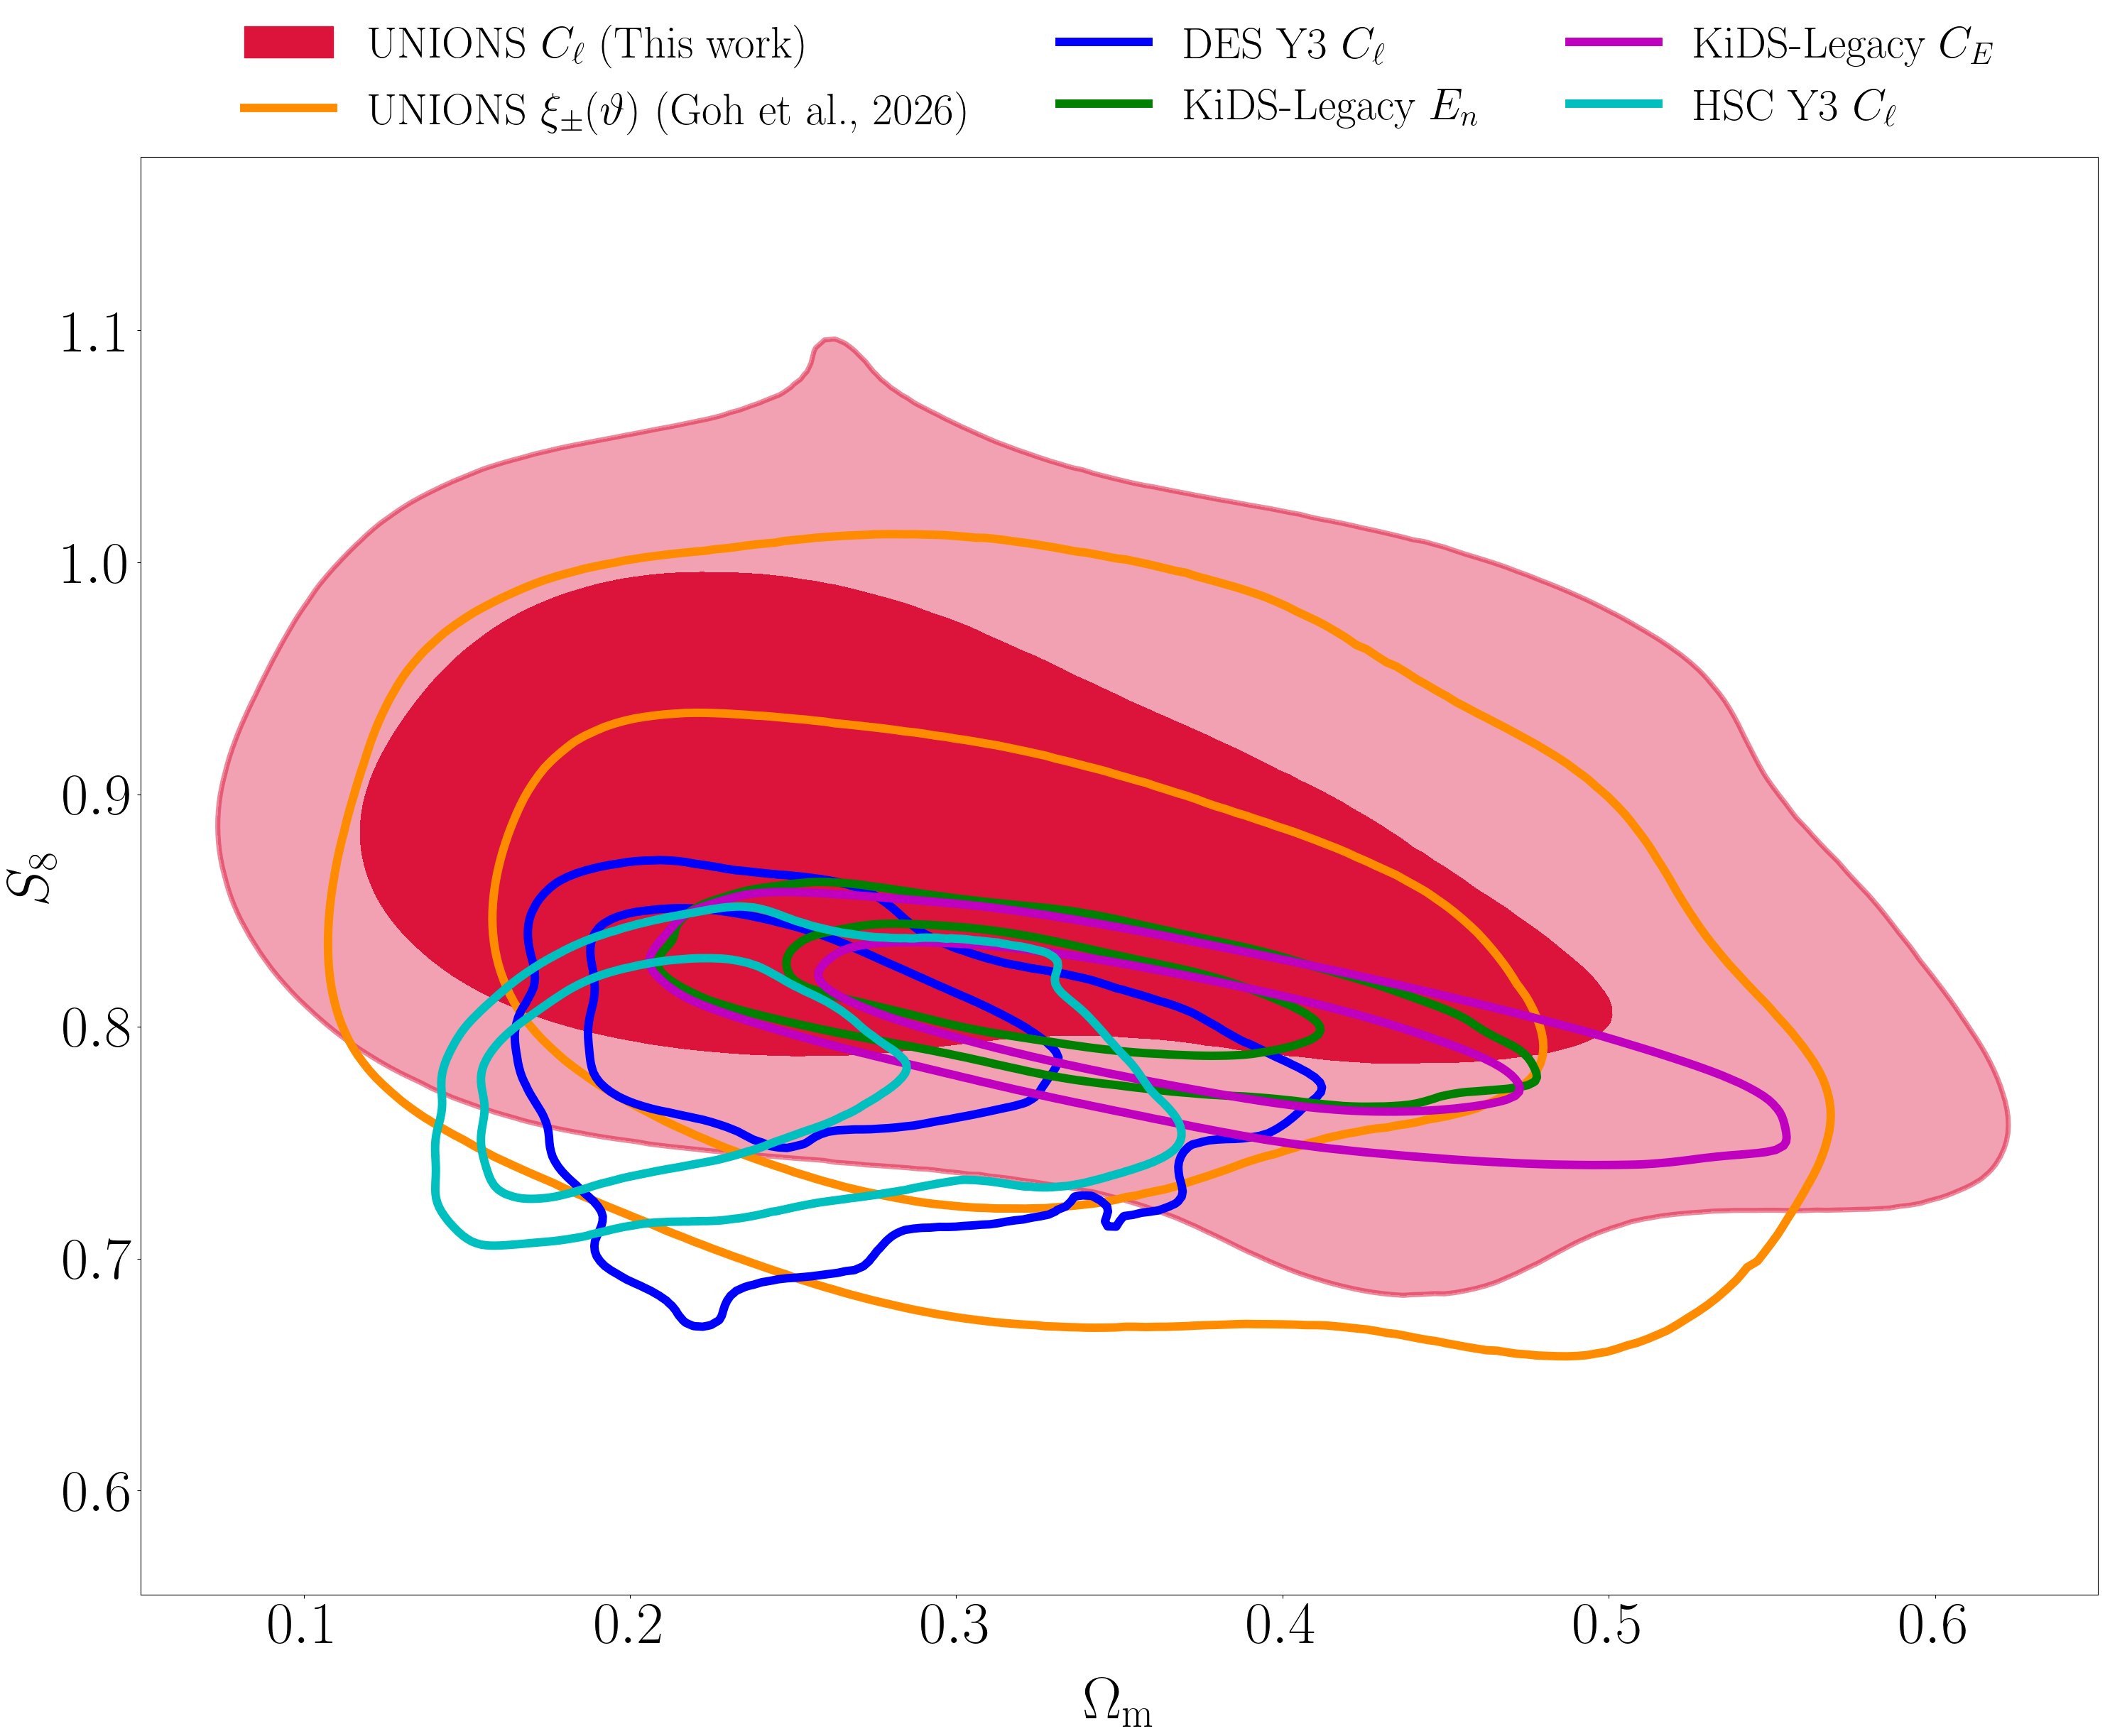

In [6]:
legend_labels = [
    r"UNIONS $C_\ell$ (This work)",
    r"UNIONS $\xi_\pm(\vartheta)$ (Goh et al., 2026)",
    r"DES Y3 $C_\ell$",
    r"KiDS-Legacy $E_n$",
    r"KiDS-Legacy $C_E$",
    r"HSC Y3 $C_\ell$",
]

colours = [
    "crimson",
    "darkorange",
]

linestyle = [
    'solid',
    'solid',
    'solid',
    'solid',
    'solid',
    'solid'
]

filled = [
    True,
    False,
    False,
    False,
    False,
    False
]

line_args = [dict(color=col, ls=ls) for col, ls in zip(colours, linestyle)]

g = plots.get_single_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 45
g.settings.figure_legend_ncol = 3
g.settings.legend_frame = False

g.plot_2d(chains,
          'OMEGA_M', 'S_8',
          filled=filled,
          line_args=line_args,
          contour_colors=colours,)

g.add_legend(
    legend_labels,
    legend_loc='upper center',
    bbox_to_anchor=(0.5, 1.12),   # moves legend above the axes
)

plt.xlim(0.05, 0.65)

plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.png", dpi=300, bbox_inches='tight')
#Save PDF
plt.savefig("plots/cosmological_constraints_weak_lensing/contours_OMEGA_M_S8_2D_weak_lensing_all_surveys.pdf", bbox_inches='tight')
plt.show()
